# Chapter 4 experiment harness

Reproduces the results chapter 4 reports: figures 4.2, 4.4, 4.5, 4.6 and 4.9, the
coalition figure of section 4.5.2, and tables 4.1 to 4.9.

One stream throughout: 200,000 events over a 16,384-key universe, Zipf with
exponent 1.2, split by event across sixteen workers in unequal batches. The
distributed histogram requires all sixteen. The decentralized histogram requires a
completion quorum of twelve, closes at the collection window or the deadline, and
checks every contribution before it enters the merge.

Nothing is reimplemented here. Each worker's vector comes from the chapter's kernel
through `worker_contribution` (listing 4.4), contributions are admitted by
`validate_histogram` (listing 4.8) and merged by `bounded_merge` (listing 4.9).
`histogram_experiments.py` drives them with seeded completion times, dropout and
adversaries, and this notebook only runs it and draws the figures.

## Environment

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import histogram_experiments as ex
import partial_histogram

print("CUDA kernel path live:", partial_histogram.gpu_available())
print("evidence class       : simulated_decentralized")
print("  the counting is real; completion times, dropout and adversaries are seeded draws")

plt.rcParams.update({"font.size": 13, "axes.labelsize": 14, "xtick.labelsize": 12,
                     "ytick.labelsize": 12, "legend.fontsize": 12, "figure.dpi": 110})
INK, ACCENT, COOL, MUTED = "#1f2933", "#b4451f", "#26619c", "#8a94a6"


def clean(ax):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


def race_pair(exact, other, label, colour):
    """CPU-exact against one kernel's counts, each bar labelled with its count."""
    exact, other = np.asarray(exact, dtype=float), np.asarray(other, dtype=float)
    x = np.arange(len(exact))
    fig, ax = plt.subplots(figsize=(8.4, 4.6))
    ax.bar(x - 0.20, exact, 0.40, color=COOL, label="exact")
    ax.bar(x + 0.20, other, 0.40, color=colour, label=label)
    if np.array_equal(exact, other):
        for xi, ev in zip(x, exact):
            ax.annotate(f"{int(ev):,}", xy=(xi, ev), xytext=(xi, ev * 1.7),
                        ha="center", fontsize=9, color=INK)
    else:
        for xi, ev, ov in zip(x, exact, other):
            ax.annotate(f"{int(ev):,}", xy=(xi - 0.20, ev), xytext=(xi - 0.20, ev * 1.7),
                        ha="center", fontsize=9, color=COOL)
            ax.annotate(f"{int(ov):,}", xy=(xi + 0.20, ov), xytext=(xi + 0.20, ov * 1.7),
                        ha="center", fontsize=9, color=colour)
    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xlabel("bin")
    ax.set_ylabel("frequency (log scale)")
    ax.set_ylim(1, exact.max() * 40)
    ax.grid(alpha=0.25, axis="y", which="major")
    ax.legend(frameon=False, loc="upper left")
    fig.tight_layout()
    plt.show()

CUDA kernel path live: True
evidence class       : simulated_decentralized
  the counting is real; completion times, dropout and adversaries are seeded draws


## 4.1.1 Figure 4.2

`kernels.cu` holds both kernels. Listing 4.1, `NaiveHistogramKernel`, increments
`h[b] += 1` with no synchronization. One million events over eight bins, about 60%
of them aimed at bin 7, counted once by `numpy.bincount` and once by the naive
kernel. The race is nondeterministic: which increments survive depends on how the
hardware scheduled the threads, so this run's counts differ from the book's sample
run (700 events surviving, 68 to 97 per bin) and from the next run.

events counted, CPU-exact     : 1,000,000
events surviving, listing 4.1 : 715 (66 to 101 per bin)


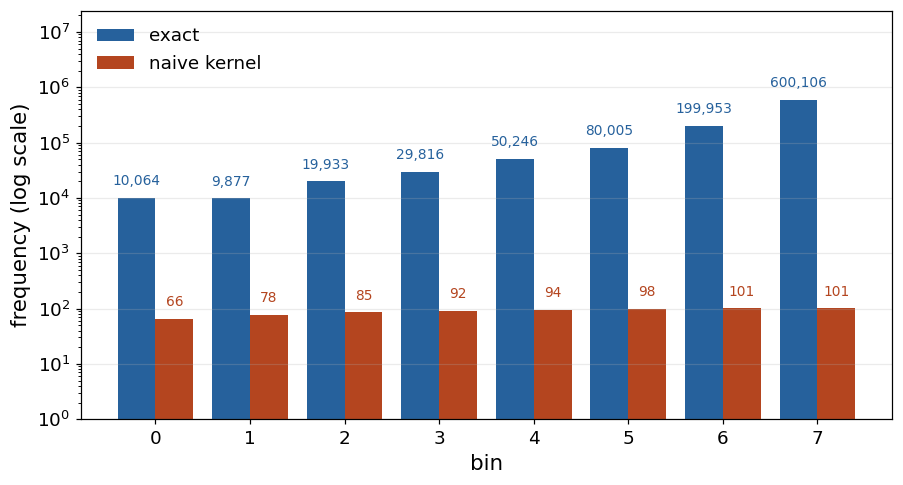

In [2]:
if partial_histogram.gpu_available():
    race = ex.race()
    print(f"events counted, CPU-exact     : {int(race['exact'].sum()):,}")
    print(f"events surviving, listing 4.1 : {int(race['naive'].sum()):,} "
          f"({race['naive'].min()} to {race['naive'].max()} per bin)")
    race_pair(race["exact"], race["naive"], "naive kernel", ACCENT)
else:
    race = None
    print("No CUDA device: there is no race to measure on the CPU path, which counts sequentially.")

## 4.1.3 Figure 4.4

The same million events through `PartialHistogramKernel` (listing 4.2), launched by
`partial_histogram` (listing 4.3): a block-private histogram in shared memory,
`atomicAdd` inside the block, and one published row per block, summed by the
launcher.

events counted, listing 4.2 : 1,000,000
matches CPU-exact           : True


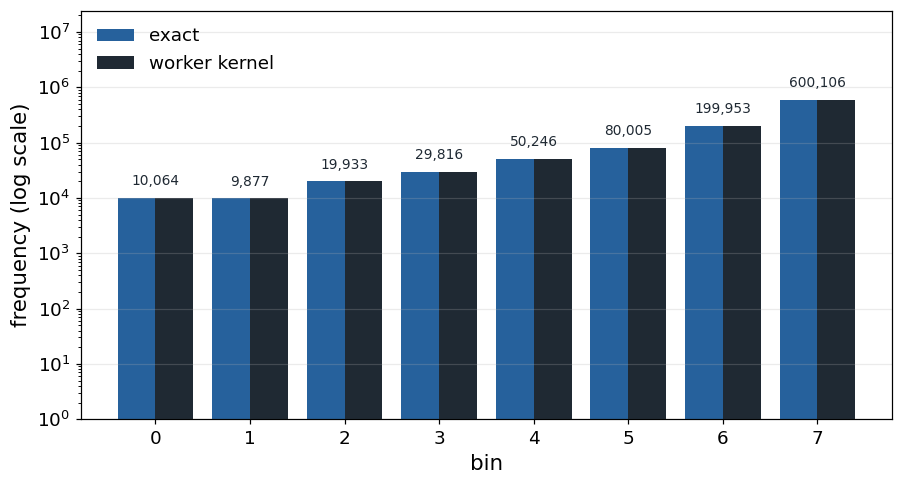

In [3]:
if race is None:
    probabilities = [0.01, 0.01, 0.02, 0.03, 0.05, 0.08, 0.20, 0.60]
    keys = np.random.default_rng(42).choice(8, size=1_000_000, p=probabilities)
    exact = np.bincount(keys, minlength=8)
    worker = partial_histogram.partial_histogram(keys, 8)[1].get()
else:
    exact, worker = race["exact"], race["worker"]
print(f"events counted, listing 4.2 : {int(worker.sum()):,}")
print(f"matches CPU-exact           : {np.array_equal(worker, exact)}")
race_pair(exact, worker, "worker kernel", INK)

## 4.2.1 Table 4.1 and figure 4.5

The reference key stream. Every worker vector below is computed by the worker
kernel through listing 4.4.

Table 4.1 The reference key stream
  workers                             16
  events                              200,000
  bins in the key universe            16,384
  distinct keys observed              10,161
  key distribution                    Zipf, exponent 1.2
  events in the hottest bin           20.65%
  events in the top 32 bins           63.64%
  smallest and largest worker batch   5,800 and 23,000 events

section 4.2.2: the owner of the hottest key carries at least 3.30 times the mean load under a key partition
worker vectors computed by: worker kernel (listing 4.2)


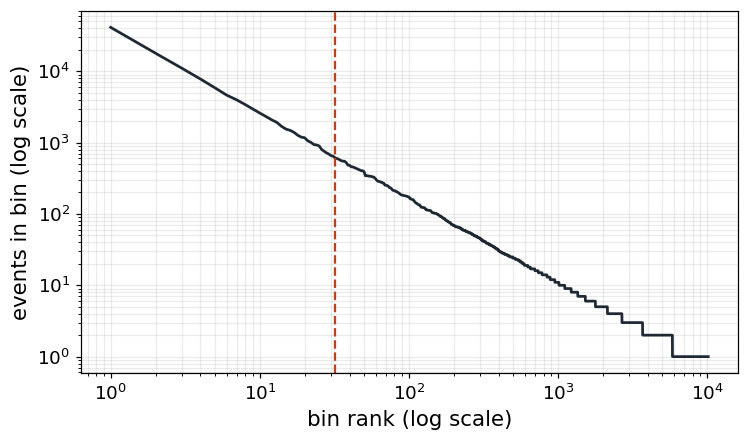

In [4]:
ref = ex.reference()
print("Table 4.1 The reference key stream")
for label, value in (("workers", f"{ref['workers']}"),
                     ("events", f"{ref['events']:,}"),
                     ("bins in the key universe", f"{ref['bins']:,}"),
                     ("distinct keys observed", f"{ref['distinct_keys']:,}"),
                     ("key distribution", "Zipf, exponent 1.2"),
                     ("events in the hottest bin", f"{100 * ref['hottest_share']:.2f}%"),
                     ("events in the top 32 bins", f"{100 * ref['top32_share']:.2f}%"),
                     ("smallest and largest worker batch",
                      f"{ref['batch_min']:,} and {ref['batch_max']:,} events")):
    print(f"  {label:36}{value}")
print(f"\nsection 4.2.2: the owner of the hottest key carries at least "
      f"{ref['busiest_key_owner_load']:.2f} times the mean load under a key partition")
print(f"worker vectors computed by: {ref['computed_by']}")

counts = np.sort(ref["truth"])[::-1]
counts = counts[counts > 0]
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.loglog(np.arange(1, counts.size + 1), counts, color=INK, lw=1.8)
ax.axvline(32, color=ACCENT, ls="--", lw=1.5)
ax.set_xlabel("bin rank (log scale)")
ax.set_ylabel("events in bin (log scale)")
ax.grid(alpha=0.25, which="both")
fig.tight_layout()
plt.show()

## 4.2.4 Table 4.2

Both models on the same 300 epochs per condition: the same completion times and the
same participation draw, so only the coordination rule changes. Quorum 12 of 16,
`α` = 1.5, deadline 2.0, completion times lognormal with median 1.0. Event
coverage and distance from CPU-exact are averaged over completed epochs.

Every block below that runs the baseline timing uses these same 300 epochs, so the
baseline row here is the Zipf 1.2 row of table 4.3 and the timing behind table 4.5.

In [5]:
def table(title, header, rows):
    print(title)
    print("  " + "".join(f"{h:>{w}}" for h, w in header))
    for r in rows:
        print("  " + "".join(f"{v:>{w}}" for v, (_h, w) in zip(r, header)))

cols = (("condition", 20), ("dist. completed", 17), ("dec. completed", 16),
        ("dec. coverage", 15), ("dec. distance", 15))
table("Table 4.2 The same epochs, under variance", cols,
      [(r["condition"], f"{r['distributed']['completed']:.2f}",
        f"{r['decentralized']['completed']:.2f}",
        f"{r['decentralized']['event_coverage']:.3f}",
        f"{r['decentralized']['distance']:.3f}") for r in ex.variance()])

Table 4.2 The same epochs, under variance
             condition  dist. completed  dec. completed  dec. coverage  dec. distance
       baseline timing             0.69            1.00          0.963          0.005
           10% dropout             0.11            0.95          0.879          0.014
            heavy tail             0.02            0.69          0.812          0.020


## 4.2.5 Tables 4.3 and 4.4

Statistical skew first: the Zipf exponent changes while the shards stay the same.
Then system skew: the key distribution stays the same while completion time scales
with shard size, and four or eight workers run three times slower.

In [6]:
table("Table 4.3 Statistical skew with event splitting",
      (("Zipf exponent", 15), ("hottest bin", 13)) + cols[1:],
      [(f"{r['alpha']}", f"{100 * r['hottest_share']:.1f}%",
        f"{r['distributed']['completed']:.2f}", f"{r['decentralized']['completed']:.2f}",
        f"{r['decentralized']['event_coverage']:.3f}",
        f"{r['decentralized']['distance']:.3f}") for r in ex.statistical_skew()])
print()
table("Table 4.4 System skew", cols,
      [(r["condition"], f"{r['distributed']['completed']:.2f}",
        f"{r['decentralized']['completed']:.2f}",
        f"{r['decentralized']['event_coverage']:.3f}",
        f"{r['decentralized']['distance']:.3f}") for r in ex.system_skew()])

Table 4.3 Statistical skew with event splitting
    Zipf exponent  hottest bin  dist. completed  dec. completed  dec. coverage  dec. distance
              0.6         0.8%             0.69            1.00          0.963          0.014
              1.2        20.7%             0.69            1.00          0.963          0.005
              1.6        43.9%             0.69            1.00          0.963          0.002



Table 4.4 System skew
             condition  dist. completed  dec. completed  dec. coverage  dec. distance
         Uneven shards             0.25            1.00          0.863          0.015
     Four slow workers             0.05            0.92          0.855          0.017
    Eight slow workers             0.00            0.35          0.805          0.021


## 4.2.6 Table 4.5

Worker 3 sends either a malformed contribution (half its vector is missing) or a
Byzantine one (every event it holds moved into the target bin, the 201st most
frequent, with its declared total kept). The influence limit is on, with `τ` = 3,
for the decentralized model. Target bin is the committed count as a multiple of its
true count, averaged over completed epochs.

In [7]:
adv = ex.one_adversary()
print(f"target bin: {adv['target_true']} true events; worker 3 holds {adv['worker3_events']:,} "
      f"and moves {adv['moved']:,} of them into it\n")
table("Table 4.5 One adversarial worker",
      (("case", 11), ("model", 15), ("completed", 11), ("rejected/epoch", 16),
       ("distance", 10), ("target bin", 12)),
      [(r["case"], r["model"], f"{r['completed']:.2f}", f"{r['rejected_per_round']:.2f}",
        "-" if r["distance"] is None else f"{r['distance']:.3f}",
        "-" if r["target_ratio"] is None else f"{r['target_ratio']:.2f}x")
       for r in adv["rows"]])

target bin: 69 true events; worker 3 holds 16,800 and moves 16,795 of them into it

Table 4.5 One adversarial worker
         case          model  completed  rejected/epoch  distance  target bin
    Malformed    Distributed       0.00            1.00         -           -
    Malformed  Decentralized       1.00            0.95     0.115       0.90x
    Byzantine    Distributed       0.69            0.00     0.084     244.41x
    Byzantine  Decentralized       1.00            0.00     0.119       1.12x


## Figure 4.6

One epoch of table 4.5's run: the first in which all sixteen workers arrive by the
deadline, so both models merge every worker. The eight heaviest bins and the target
bin. Table 4.5 averages the target bin over every completed epoch; this is one of
those epochs.

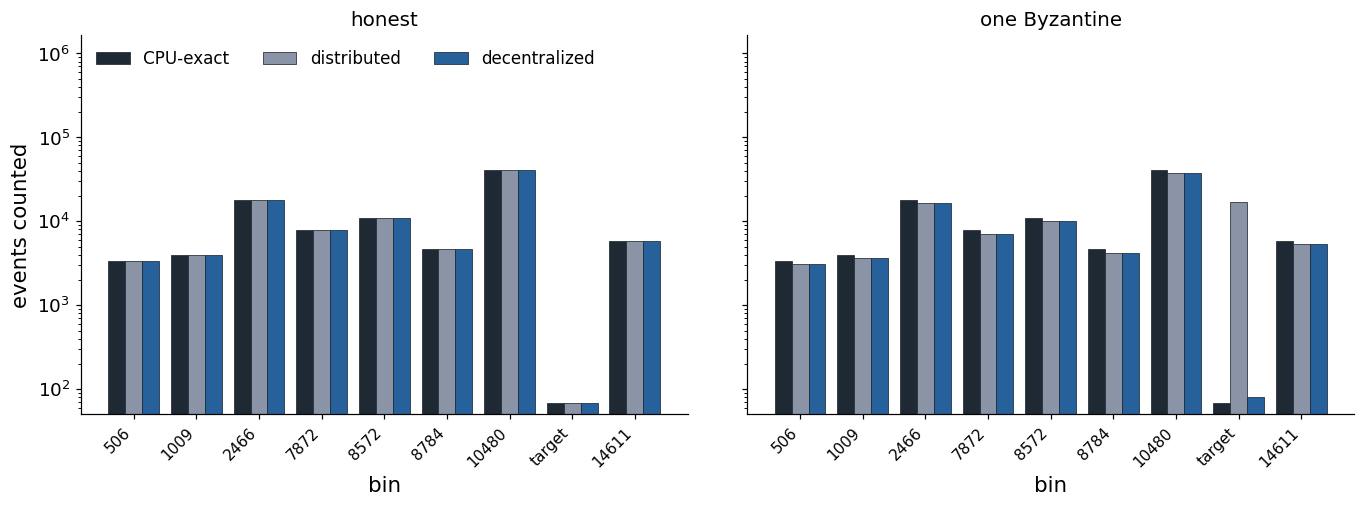

target bin in this epoch: CPU-exact 69, distributed 16,864, decentralized 80


In [8]:
sh = ex.shapes()
labels = ["target" if b == sh["target"] else str(b) for b in sh["bins"]]
x = np.arange(len(sh["bins"]))
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8), sharey=True)
for ax, case in zip(axes, ("honest", "one Byzantine")):
    for i, (name, vals, colour) in enumerate((("CPU-exact", sh["cpu"], INK),
                                              ("distributed", sh[case]["distributed"], MUTED),
                                              ("decentralized", sh[case]["decentralized"], COOL))):
        ax.bar(x + (i - 1) * 0.27, vals, 0.27, label=name, color=colour,
               edgecolor=INK, linewidth=0.5)
    ax.set_yscale("log")
    ax.set_ylim(top=max(sh["cpu"]) * 40)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
    ax.set_title(case, fontsize=13)
    ax.set_xlabel("bin")
    clean(ax)
axes[0].set_ylabel("events counted")
axes[0].legend(frameon=False, loc="upper left", ncol=3, fontsize=11)
fig.tight_layout()
plt.show()
i = sh["bins"].index(sh["target"])
print(f"target bin in this epoch: CPU-exact {sh['cpu'][i]}, "
      f"distributed {sh['one Byzantine']['distributed'][i]:,}, "
      f"decentralized {sh['one Byzantine']['decentralized'][i]}")

## Table 4.6

A coalition of Byzantine workers moves every event it holds into the same target
bin. Every worker is present and on time, so completion is held constant and only
the coalition's size changes.

In [9]:
coal = ex.coalition()
table("Table 4.6 Colluding workers targeting the same bin",
      (("colluding of 16", 17), ("distributed", 14), ("decentralized", 15)),
      [(f"{r['colluding']}", f"{r['distributed']:,.2f}x", f"{r['decentralized']:,.2f}x")
       for r in coal["rows"] if r["colluding"] in (0, 7, 8, 16)])
print(f"\nthe influence limit holds through {coal['holds_through']} colluding workers")

Table 4.6 Colluding workers targeting the same bin
    colluding of 16   distributed  decentralized
                  0         1.00x          1.00x
                  7     1,748.17x          2.97x
                  8     1,924.91x      1,924.91x
                 16     2,898.55x      2,898.55x

the influence limit holds through 7 colluding workers


## 4.5.1 Table 4.7

One fixed accepted set: all sixteen workers present and on time. Worker 3 is
honest, malformed or Byzantine, with the influence limit off and with `τ` = 3.
Top-32 recall is the fraction of the true 32 heaviest bins still in the result's
top 32.

In [10]:
beh = ex.one_worker_behaviors()
table("Table 4.7 One worker, each behavior, with and without the limit",
      (("behavior", 11), ("admission", 11), ("target, off", 13), ("target, on", 12),
       ("TVD, off", 10), ("TVD, on", 9), ("recall, off", 13), ("recall, on", 12)),
      [(r["behavior"], r["admission"], f"{r['target_off']:,}", f"{r['target_on']:,}",
        f"{r['tvd_off']:.3f}", f"{r['tvd_on']:.3f}", f"{r['recall_off']:.2f}",
        f"{r['recall_on']:.2f}") for r in beh["rows"]])
print(f"\ntarget bin: {beh['target_true']} events, {100 * beh['target_share']:.4f}% of the stream")
print(f"honest fleet, tau = 3: {beh['removed_tau3']:,} counts removed, "
      f"{beh['removed_from_heavy_bins']} of them from the 32 heaviest bins")
print(f"bins observed by fewer than half the workers: {100 * beh['zero_median_bin_share']:.1f}% "
      f"of bins, holding {100 * beh['zero_median_event_share']:.1f}% of the events")
print(f"raising tau from 3 to 1,000 recovers {beh['recovered_tau3_to_1000']:,} counts")

Table 4.7 One worker, each behavior, with and without the limit
     behavior  admission  target, off  target, on  TVD, off  TVD, on  recall, off  recall, on
       honest   accepted           69          69     0.000    0.113         1.00        1.00
    malformed   rejected           64          64     0.011    0.115         1.00        1.00
    Byzantine   accepted       16,864          80     0.084    0.119         0.97        1.00

target bin: 69 events, 0.0345% of the stream
honest fleet, tau = 3: 23,102 counts removed, 0 of them from the 32 heaviest bins
bins observed by fewer than half the workers: 93.8% of bins, holding 10.8% of the events
raising tau from 3 to 1,000 recovers 1,546 counts


## 4.5.2 The coalition figure

The committed count on the target bin as the coalition grows, from the same sweep
as table 4.6. The dashed line marks where the influence limit stops constraining
the attack.

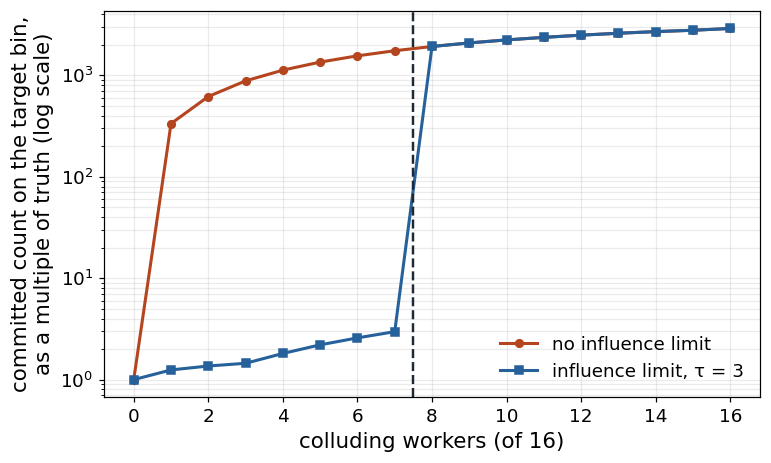

In [11]:
rows = coal["rows"]
sizes = [r["colluding"] for r in rows]
fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(sizes, [r["distributed"] for r in rows], "-o", color=ACCENT, lw=2.0, ms=5,
        label="no influence limit")
ax.plot(sizes, [r["decentralized"] for r in rows], "-s", color=COOL, lw=2.0, ms=5,
        label="influence limit, \u03c4 = 3")
ax.axvline(coal["holds_through"] + 0.5, color=INK, ls="--", lw=1.6)
ax.set_yscale("log")
ax.set_xlabel("colluding workers (of 16)")
ax.set_ylabel("committed count on the target bin,\nas a multiple of truth (log scale)")
ax.grid(alpha=0.25, which="both")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

## 4.5.3 Table 4.8

Dense, sparse and bounded payloads as the key universe grows. Fill and bytes are
the largest worker's (23,000 events); recall and TVD are measured after all sixteen
capacity-256 Misra-Gries summaries are merged. Beyond the per-block shared-memory
limit, listing 4.2 cannot privatize the universe and the worker vectors are counted
on the host.

In [12]:
rep = ex.representation()
table("Table 4.8 Representation size as the key universe grows",
      (("bins", 8), ("fill", 8), ("dense", 9), ("sparse", 9), ("bounded", 9),
       ("recall", 8), ("TVD", 7)),
      [(f"{r['bins']:,}", f"{100 * r['fill']:.1f}%", f"{r['dense']:,}", f"{r['sparse']:,}",
        f"{r['bounded']:,}", f"{r['recall']:.2f}", f"{r['tvd']:.3f}") for r in rep])
print()
for r in rep:
    print(f"  {r['bins']:>6,} bins: worker vectors by {r['computed_by']}")
print(f"\nmedian worker at 16,384 bins: {ref['median_distinct_keys']:,} bins touched, "
      f"{8 * ref['median_distinct_keys']:,} sparse bytes")
for nbytes in (65_536, 24_920, 8 * ref["median_distinct_keys"], 2_048):
    print(f"  {nbytes:>6,} bytes at 5 Mbit/s: {nbytes * 8 / 5e6 * 1000:.1f} ms")

Table 4.8 Representation size as the key universe grows
      bins    fill    dense   sparse  bounded  recall    TVD
     1,024   91.6%    4,096    7,504    2,048    1.00  0.207
     4,096   51.1%   16,384   16,736    2,048    1.00  0.279
    16,384   19.0%   65,536   24,920    2,048    1.00  0.325
    32,768   10.7%  131,072   28,032    2,048    1.00  0.338
    65,536    5.9%  262,144   30,696    2,048    1.00  0.352

   1,024 bins: worker vectors by worker kernel (listing 4.2)
   4,096 bins: worker vectors by worker kernel (listing 4.2)
  16,384 bins: worker vectors by worker kernel (listing 4.2)
  32,768 bins: worker vectors by host histogram (beyond shared memory)
  65,536 bins: worker vectors by host histogram (beyond shared memory)

median worker at 16,384 bins: 1,922 bins touched, 15,376 sparse bytes
  65,536 bytes at 5 Mbit/s: 104.9 ms
  24,920 bytes at 5 Mbit/s: 39.9 ms
  15,376 bytes at 5 Mbit/s: 24.6 ms
   2,048 bytes at 5 Mbit/s: 3.3 ms


## 4.5.4 Table 4.9 and figure 4.9

Three dropout patterns at nearly the same coverage. Uniform: every worker present
with probability 0.75. Differential: even workers 0.95, odd workers 0.55. Differential
and correlated: the same probabilities, with the rare tail of the key distribution
dealt to the odd workers. 400 draws each, measured over the epochs that reach
quorum. Predicted bias is equation 4.5.

Table 4.9 Coverage under different missing-worker patterns
                         regime  workers   events  deviation    bias  predicted
                uniform dropout   82.03%   81.96%     0.0196  0.0012     0.0000
           differential dropout   80.88%   81.51%     0.0201  0.0092     0.0115
    differential and correlated   80.88%   81.51%     0.0307  0.0184     0.0234

committed epochs of 400 draws: 249, 254, 254


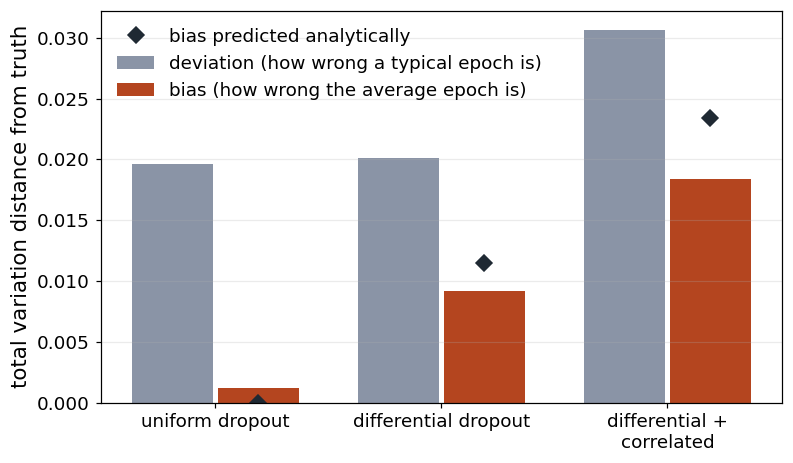

In [13]:
bias = ex.selection_bias()
table("Table 4.9 Coverage under different missing-worker patterns",
      (("regime", 29), ("workers", 9), ("events", 9), ("deviation", 11), ("bias", 8),
       ("predicted", 11)),
      [(r["regime"], f"{100 * r['worker_coverage']:.2f}%", f"{100 * r['event_coverage']:.2f}%",
        f"{r['deviation']:.4f}", f"{r['bias']:.4f}", f"{r['predicted_bias']:.4f}") for r in bias])
print("\ncommitted epochs of 400 draws: " + ", ".join(str(r["committed_rounds"]) for r in bias))

labels = [r["regime"].replace(" and ", " +\n") for r in bias]
x = np.arange(len(bias))
fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.bar(x - 0.19, [r["deviation"] for r in bias], 0.36, color=MUTED,
       label="deviation (how wrong a typical epoch is)")
ax.bar(x + 0.19, [r["bias"] for r in bias], 0.36, color=ACCENT,
       label="bias (how wrong the average epoch is)")
ax.plot(x + 0.19, [r["predicted_bias"] for r in bias], "D", color=INK, ms=7,
        label="bias predicted analytically")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("total variation distance from truth")
ax.grid(alpha=0.25, axis="y")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

## What the harness does not show

**The network.** Workers are seeded completion times, not machines. Every close
time is in units of the median worker's completion time, and every dropout is a
coin flip per worker per epoch. That is what `simulated_decentralized` means.

**Wall-clock coordination.** `decentralized_histogram.py` runs listing 4.10 for
real, with threads as workers and the wall clock as time:
`python decentralized_histogram.py`. Listing 4.5 runs the same way from
`distributed_histogram.py`, and listing 4.6 runs a four-process All-Reduce from
`allreduce_histogram.py`.

**A real adversary.** The Byzantine workers here follow one fixed strategy: move
every event into one bin. Table 4.6 shows where the median-based limit stops
helping against that strategy, not against every strategy.